# Projet final — Timing de la volatilité réalisée pour une stratégie de carry sur volatilité

# Cagla Amiklioglu et Marie Abbyad

Ce notebook présente notre projet final de **Volatility Trading**, consacré au **timing de la volatilité réalisée** dans le cadre d’une stratégie de carry sur options.

L’objectif du projet est d’explorer si une estimation dynamique de la volatilité réalisée peut améliorer l’exécution d’une stratégie de vente de volatilité. Plus précisément, nous cherchons à estimer une variance latente $v_t$ à l’aide d’un **modèle d’état inspiré de Heston** et d’un **Unscented Kalman Filter (UKF)**, puis à comparer cette estimation à la volatilité implicite observée sur le marché.

Le signal central du projet est le spread quotidien entre volatilité implicite et volatilité réalisée estimée :

$s_t = \sigma_{IV,t} - \hat{\sigma}_t$

L’intuition économique est la suivante : lorsque la volatilité implicite est suffisamment supérieure à la volatilité réalisée anticipée, une stratégie de carry sur volatilité est en principe plus attractive. À l’inverse, lorsque cet écart se réduit ou devient négatif, l’exposition à la stratégie doit être réduite.

Dans ce notebook, nous procédons en quatre étapes :
1. construction d’une stratégie baseline de type **short volatility carry** ;
2. estimation de la volatilité réalisée latente via un modèle UKF-Heston ;
3. construction d’un signal de timing fondé sur le spread IV-RV ;
4. comparaison entre une stratégie **statique** et une stratégie **dynamique** utilisant ce signal.

Dans le rendu principal, nous retenons **SPY** comme sous-jacent de référence. Néanmoins, le notebook reste **paramétrable** : en modifiant simplement la variable `ticker` ainsi que le fichier de data en input, la même méthodologie peut être relancée sur un autre sous-jacent, par exemple **AAPL**.

## 1) Environnement de travail et logique générale du notebook

Cette première partie rassemble les bibliothèques et modules nécessaires à l’ensemble de l’analyse.

Le notebook s’appuie à la fois sur des librairies standards de calcul scientifique et de visualisation, et sur les modules développés pour le projet afin de :
- charger les données d’options ;
- construire les séries nécessaires au signal ;
- estimer la variance latente avec un modèle inspiré de Heston ;
- appliquer un filtre de Kalman non linéaire de type UKF ;
- transformer le signal obtenu en allocation dynamique ;
- backtester la stratégie et comparer les performances.

L’objectif est de conserver un notebook **reproductible**, **facile à relancer**, et suffisamment modulaire pour tester la même méthode sur plusieurs sous-jacents en modifiant simplement le paramètre `ticker`.

In [27]:
from datetime import datetime
import numpy as np
import pandas as pd

from investment_lab.data.option_db import OptionLoader, AAPLOptionLoader, extract_spot_from_options
from investment_lab.option_trade import DeltaHedgedOptionTrade, OptionTrade
from investment_lab.option_strategies import SHORT_1W_STRADDLE
from investment_lab.backtest import BacktesterBidAskFromData
from investment_lab.stochastic.heston_ssm import HestonParams, HestonStateSpaceModel
from investment_lab.stochastic.ukf import ScalarUnscentedKalmanFilter
from investment_lab.stochastic.heston_mle import fit_heston_params_rolling
from investment_lab.allocation import compute_linear_weights, rescale_positions_with_signal
from investment_lab.metrics.performance import format_perf_table
from investment_lab.plots import plot_results

## 2) Données utilisées et choix du sous-jacent

L’analyse repose sur la base d’options utilisée pendant le cours, qui contient les informations nécessaires à la construction et au backtest de stratégies sur options : prix du sous-jacent, caractéristiques des contrats, volatilités implicites, greeks et éléments d’exécution.

Dans le cadre du rendu principal, nous retenons **SPY** comme sous-jacent de référence.

Dans cette section, nous chargeons donc les données correspondant au sous-jacent choisi et nous préparons les séries qui serviront ensuite à l’estimation de la volatilité réalisée et au backtest de la stratégie.

Ici les dates START et END sont les mêmes pour le **SPY** et **AAPL** malgré qu'on ait un plus long historique sur **AAPL** car nous avons des données pour la courbe des taux entre 2020 et 2022.

In [2]:
START = datetime(2020, 1, 2)
END = datetime(2022, 12, 30)

# =========================
# Cas principal : SPY
# =========================

TICKER = "SPY"
df_options  = OptionLoader.load_data(start_date=START, end_date=END, process_kwargs={"ticker": TICKER})

# ============================================
# Variante possible : AAPL
# ============================================

"""
TICKER = "AAPL"
df_options = AAPLOptionLoader.load_data(start_date=START, end_date=END, process_kwargs={"ticker": TICKER})
"""

'\nTICKER = "AAPL"\ndf_options = AAPLOptionLoader.load_data(start_date=START, end_date=END, process_kwargs={"ticker": TICKER})\n'

## 3) Construction des rendements et préparation des séries d’entrée

À partir de la base d’options, nous extractons d’abord le prix du sous-jacent afin de construire une série temporelle cohérente du spot.

Nous calculons ensuite les **log-rendements journaliers**, qui serviront de variable observée dans notre modèle d’état inspiré de Heston. En effet, dans ce cadre, le prix est observé alors que la variance instantanée $v_t$ est latente. Les rendements constituent donc l’entrée naturelle pour estimer dynamiquement cette variance à l’aide du filtre UKF.

Cette étape permet de préparer la série de marché qui servira ensuite à :
- calibrer les paramètres du modèle en fenêtre glissante ;
- filtrer la variance latente ;
- construire une estimation de la volatilité réalisée.

In [3]:
df_spot = extract_spot_from_options(df_options).set_index("date")["spot"]
log_returns = np.log(df_spot / df_spot.shift(1)).dropna()

## 4) Estimation de la variance latente avec un modèle UKF-Heston (deux spécifications)

Cette section met en œuvre un modèle d’état inspiré de Heston pour estimer la variance latente $v_t$ à partir des log-rendements observés.

Le modèle discret utilisé est :

$$
\begin{cases}
dS_t = \mu S_t dt + S_t \sqrt{v_t} dW_{1,t} \\
dv_t = \kappa(\theta - v_{t}) dt + \xi\sqrt{v_{t}}  dW_{2,t}
\end{cases}
$$
$$
\Leftrightarrow
$$
$$
\begin{cases}
r_t = \mu \Delta t + \sqrt{v_t\Delta t}\,\varepsilon_{1,t} \\
v_t = v_{t-1} + \kappa(\theta - v_{t-1})\Delta t + \xi\sqrt{v_{t-1}\Delta t}\,\varepsilon_{2,t}
\end{cases}
$$

avec $r_t$ les log rendements de $S_t$ et

$\varepsilon_{1,t} = \rho \varepsilon_{2,t} + \sqrt{1-\rho^2}\,\varepsilon_{\perp,t}$

ce qui impose bien la corrélation $\mathrm{Corr}(dW_1,dW_2)=\rho$.

Nous utilisons un **Unscented Kalman Filter (UKF)** (version état augmenté) afin de préserver cette structure de corrélation dans l’étape de filtrage.


On conserve la même dynamique d’état de variance (type Heston), et on teste deux spécifications de l’équation d’observation des log-rendements :

- Cas A (`heston=True`) - Heston : $\mathbb{E}[r_t \mid v_t] = \mu \Delta_t$
- Cas B (`heston=False`) - Heston mean modified : $\mathbb{E}[r_t \mid v_t] = (\mu - \tfrac{1}{2}v_t)\Delta_t$

**Remarque :** pour simplifier l'écriture, nous appelons le Cas B, Heston mean modified même si en réalité c'est l'espérance qui est modifiée et nous devrions ainsi appeler les variables expected value modified.

Les équations pour le Cas B deviennent alors :

$$
\begin{cases}
r_t = \left(\mu - \frac{1}{2}v_t\right)\Delta t + \sqrt{v_t\Delta t}\,\varepsilon_{1,t} \\
v_t = v_{t-1} + \kappa(\theta - v_{t-1})\Delta t + \xi\sqrt{v_{t-1}\Delta t}\,\varepsilon_{2,t}
\end{cases}
$$


Dans les deux cas, le filtre UKF est en état augmenté pour respecter la corrélation entre chocs de rendement et de variance $(\rho)$.

Calibration :
- fenêtre glissante de 63 jours ;
- maximisation de la log-vraisemblance UKF ;
- recalibration rolling tous les 5 jours (`recalib_every = 5`).

On obtient deux estimations $\hat{\sigma}_t=\sqrt{\hat{v}_t}$, une par spécification.


Nous introduisons un cas B : **Heston Expected Value Modified** (Heston mean modified) comme extension méthodologique, correspondant à la discrétisation obtenue via la formule d'Itô. Concrètement, il introduit un terme de correction dans l’espérance conditionnelle des log-rendements : $-\frac{1}{2} v_t$.

In [4]:
# ============================================================
# Estimation rolling UKF-Heston + signal IV-RV + backtest
# ============================================================

# Paramètres de calibration / filtrage
# alpha=0.1 avoids unstable sigma-point weights in this 1D UKF setup.

def compute_kalman(heston : bool = True):
    ukf = ScalarUnscentedKalmanFilter(alpha=0.1)
    window = 63
    recalib_every = 5  #rolling MLE recalibration

    r = log_returns.values
    n = len(r)

    # Init from short window variance (annualized)
    init_state = float(np.var(r[:min(21, n)]) * 252)
    init_var = 1e-3
    m_prev, p_prev = init_state, init_var

    params = HestonParams(kappa=2.0, theta=0.04, xi=0.30, rho=-0.5, mu=0.0)
    model = HestonStateSpaceModel(params, heston=heston)

    v_filt = np.zeros(n)
    v_var = np.zeros(n)
    kappas = np.zeros(n)
    thetas = np.zeros(n)
    xis = np.zeros(n)
    rhos = np.zeros(n)
    mus = np.zeros(n)

    for t in range(n):
        if t >= window and t % recalib_every == 0:
            fit = fit_heston_params_rolling(r[t - window: t], ukf=ukf, heston=heston)
            params = fit.params
            model = HestonStateSpaceModel(params, heston=heston)

        res = ukf.filter([r[t]], model=model, init_state=m_prev, init_var=p_prev, measurement_var=1e-8)
        m_prev = float(res.filtered_state[-1])
        p_prev = float(res.filtered_var[-1])

        v_filt[t] = m_prev
        v_var[t] = p_prev
        kappas[t] = params.kappa
        thetas[t] = params.theta
        xis[t] = params.xi
        rhos[t] = params.rho
        mus[t] = params.mu

    kalman_result = pd.DataFrame(
        {
            "v_filtered": v_filt,
            "sigma_filtered": np.sqrt(np.maximum(v_filt, 0.0)),
            "log_return": r,
            "kappa": kappas,
            "theta": thetas,
            "xi": xis,
            "rho": rhos,
            "mu": mus,
        },
        index=log_returns.index,
    )
    return kalman_result

In [5]:
kalman_result_heston = compute_kalman(heston=True)
kalman_result_heston_mean_modified = compute_kalman(heston=False)

print("sigma_hat diagnostics Heston:")
print(kalman_result_heston["sigma_filtered"].describe(percentiles=[0.95, 0.99]))

print("sigma_hat diagnostics Heston mean modified:")
print(kalman_result_heston_mean_modified["sigma_filtered"].describe(percentiles=[0.95, 0.99]))

sigma_hat diagnostics Heston:
count    757.000000
mean       0.230569
std        0.124268
min        0.000001
95%        0.456197
99%        0.704749
max        0.800955
Name: sigma_filtered, dtype: float64
sigma_hat diagnostics Heston mean modified:
count    757.000000
mean       0.299098
std        0.230975
min        0.000001
95%        0.746180
99%        1.191861
max        1.342654
Name: sigma_filtered, dtype: float64


Cette étape fournit deux séries de volatilité réalisée estimée $\hat{\sigma}_t$, correspondant aux deux spécifications (`heston=True` / `heston=False`).

Ces séries sont ensuite comparées à la volatilité implicite de marché pour construire deux spreads IV–RV, puis deux allocations dynamiques.

À ce stade, il ne s’agit pas encore d’un signal de trading complet, mais d’une brique intermédiaire essentielle. L’objectif de la section suivante sera de comparer cette volatilité réalisée estimée à la volatilité implicite observée sur le marché, afin de construire un spread IV–RV exploitable dans la stratégie.


## 5) Construction du spread IV–RV et du signal dynamique

Le proxy IV est commun aux deux cas :
- options **Call** ;
- cotations valides $(bid>0$, $ask>0$, $IV>0$) ;
- sélection proche ATM ;
- maturité cible autour de 30 jours.

On construit ensuite deux spreads :
- $s_t^{(A)} = \sigma_{IV,t} - \hat{\sigma}_t^{(A)}$ pour `heston=True`
- $s_t^{(B)} = \sigma_{IV,t} - \hat{\sigma}_t^{(B)}$ pour `heston=False`

Puis on calcule un poids dynamique $w_t=f(s_t)$ pour chaque cas.

Remarque anti look-ahead :
pas de lag manuel ajouté sur $s_t$, l’exécution du backtest étant déjà décalée au jour ouvré suivant.



In [6]:
# ============================================================
# Construction du proxy d'IV et du spread IV - RV estimée
# ============================================================

# Coherent IV proxy: valid quote, near-ATM, around 30D maturity.
atm_proxy = (
    df_options
    .query("call_put == 'C' and implied_volatility > 0 and bid > 0 and ask > 0")
    .assign(
        mny_dist=lambda d: (d["moneyness"] - 1).abs(),
        dte_dist=lambda d: (d["day_to_expiration"] - 30).abs(),
    )
    .sort_values(["date", "dte_dist", "mny_dist"])
    .groupby("date")
    .first()[["implied_volatility", "day_to_expiration"]]
)
atm_iv = atm_proxy["implied_volatility"]

print("ATM IV proxy diagnostics:")
print("iv==0 count:", int((atm_proxy["implied_volatility"] == 0).sum()))
print("dte<=5 count:", int((atm_proxy["day_to_expiration"] <= 5).sum()))
print(atm_proxy["day_to_expiration"].describe())

spread_heston = (
    atm_iv
    .sub(kalman_result_heston["sigma_filtered"])
    # No manual lag here: backtester already executes on next business day.
    .dropna()
    .rename("iv_rv_spread")
)

spread_heston_mean_modified = (
    atm_iv
    .sub(kalman_result_heston_mean_modified["sigma_filtered"])
    # No manual lag here: backtester already executes on next business day.
    .dropna()
    .rename("iv_rv_spread")
)

dynamic_weights_heston = compute_linear_weights(spread_heston, w_min=0.0, w_max=1.0, window=63)
dynamic_weights_heston_mean_modified = compute_linear_weights(spread_heston_mean_modified, w_min=0.0, w_max=1.0, window=63)

ATM IV proxy diagnostics:
iv==0 count: 0
dte<=5 count: 0
count    758.000000
mean      29.820580
std        0.834841
min       28.000000
25%       29.000000
50%       30.000000
75%       30.000000
max       32.000000
Name: day_to_expiration, dtype: float64


Le contrôle qualité du proxy IV confirme sa cohérence : aucune volatilité implicite nulle n’est retenue, aucune maturité très courte (<=5 jours) n’est sélectionnée, et la maturité des options retenues est fortement concentrée autour de 30 jours (moyenne 29.8 jours, écart-type 0.83, intervalle [28;32]). Le spread IV–RV est donc construit sur une base de marché propre et homogène.


## 6) Construction des portefeuilles : statique vs dynamiques (2 cas)

On compare :
- 1 portefeuille statique (baseline) ;
- 2 portefeuilles dynamiques (un par spécification UKF).

La comparaison est faite avec et sans delta-hedging, afin d’isoler l’apport du signal IV–RV et l’effet de la couverture delta.


In [7]:
# ============================================================
# Construction des portefeuilles : versions statique et dynamique
# avec et sans delta hedging
# ============================================================

# 1) Portefeuille statique avec delta hedging
df_positions_static = DeltaHedgedOptionTrade.generate_trades(
    start_date=START,
    end_date=END,
    tickers=[TICKER],
    legs=SHORT_1W_STRADDLE,
)

# 2) Portefeuille statique sans delta hedging
df_positions_static_wo_delta = OptionTrade.generate_trades(
    start_date=START,
    end_date=END,
    tickers=[TICKER],
    legs=SHORT_1W_STRADDLE,
)

# 3) Application du signal dynamique aux deux portefeuilles

# 3.1) Cas Heston classique
df_positions_dynamic_heston = rescale_positions_with_signal(
    df_positions_static,
    dynamic_weights_heston,
)

df_positions_dynamic_heston_wo_delta = rescale_positions_with_signal(
    df_positions_static_wo_delta,
    dynamic_weights_heston,
)

# 3.2) Cas Heston avec moyenne modifiée
df_positions_dynamic_heston_mean_modified = rescale_positions_with_signal(
    df_positions_static,
    dynamic_weights_heston_mean_modified,
)

df_positions_dynamic_heston_mean_modified_wo_delta = rescale_positions_with_signal(
    df_positions_static_wo_delta,
    dynamic_weights_heston_mean_modified,
)

In [8]:
# ============================================================
# Backtests
# ============================================================

backtester_static = BacktesterBidAskFromData(df_positions_static).compute_backtest()
backtester_dynamic_heston = (
    BacktesterBidAskFromData(df_positions_dynamic_heston).compute_backtest())
backtester_dynamic_heston_mean_modified = (
    BacktesterBidAskFromData(df_positions_dynamic_heston_mean_modified).compute_backtest())

backtester_static_wo_delta = BacktesterBidAskFromData(
    df_positions_static_wo_delta
).compute_backtest()

backtester_dynamic_heston_wo_delta = BacktesterBidAskFromData(
    df_positions_dynamic_heston_wo_delta
).compute_backtest()

backtester_dynamic_heston_mean_modified_wo_delta = BacktesterBidAskFromData(
    df_positions_dynamic_heston_mean_modified_wo_delta
).compute_backtest()

100%|██████████| 774/774 [00:02<00:00, 279.36it/s]


In [9]:
# ============================================================
# Tableaux de performance
# ============================================================
display(format_perf_table({
    "Static (delta-hedged carry)": backtester_static.nav,
    "Dynamic (UKF spread signal) Heston": backtester_dynamic_heston.nav,
    "Dynamic (UKF spread signal) Heston mean modified": backtester_dynamic_heston_mean_modified.nav,
}))

print("--------------------------------------------------------------------------------")

display(format_perf_table({
    "Static w.o. delta hedging ": backtester_static_wo_delta.nav,
    "Dynamic Heston w.o. delta hedging ": backtester_dynamic_heston_wo_delta.nav,
    "Dynamic Heston mean modified w.o. delta hedging ": backtester_dynamic_heston_mean_modified_wo_delta.nav,
}))

,Static (delta-hedged carry),Dynamic (UKF spread signal) Heston,Dynamic (UKF spread signal) Heston mean modified
Ann. Return,2.43%,1.15%,1.68%
Ann. Vol,6.20%,2.42%,3.05%
Sharpe,0.392,0.476,0.551
Max DD,-9.05%,-4.86%,-5.30%
Calmar,0.269,0.237,0.317


--------------------------------------------------------------------------------


,Static w.o. delta hedging,Dynamic Heston w.o. delta hedging,Dynamic Heston mean modified w.o. delta hedging
Ann. Return,2.51%,0.98%,1.32%
Ann. Vol,7.45%,2.96%,3.63%
Sharpe,0.337,0.330,0.364
Max DD,-8.42%,-4.75%,-6.55%
Calmar,0.298,0.206,0.202


### Interprétation des résultats

Les résultats sont cohérents avec la logique du signal IV–RV dynamique. Nous obtenons des résultats similaires avec et sans delta hedging :

- Les versions dynamiques réduisent fortement le risque (volatilité et drawdown) qui est près de divisé par deux par rapport au cas statique.
- Cette réduction du risque se traduit en revanche par une baisse du rendement annualisé.
- Le cas **Dynamic (UKF spread signal) Heston mean modified** offre le meilleur ratio de Sharpe, ce qui suggère une meilleure efficacité risque/rendement.


Le cas delta hedgé par rapport au cas non delta hedgé permet :

- De meilleurs returns pour les versions dynamiques.
- Une baisse de la volatilité dans tous les cas.
- Des ratios de Sharpe meilleurs dans tous les cas.
- Une amélioration du drawdown dans le cas Heston mean modified (expected value modified).

**Conclusion pratique :**
Le signal UKF est pertinent pour piloter l’exposition et lisser le profil de risque.
Sur cet échantillon, la version **Heston mean modified** est la plus robuste, surtout en portefeuille delta hedgé.

## 7) Analyse graphique

Les graphiques permettent de vérifier la cohérence du pipeline :

1. NAV statique vs dynamique ;
2. spread $s_t$ et poids dynamique $w_t$ ;
3. comparaison $\hat{\sigma}_t$ (UKF-Heston) vs volatilité réalisée rolling.

Points de contrôle visuel :
- absence de pics artificiels extrêmes de $\hat{\sigma}_t$ ;
- relation intuitive entre spread et allocation ;
- comportement de la NAV dynamique cohérent avec les phases de spread.


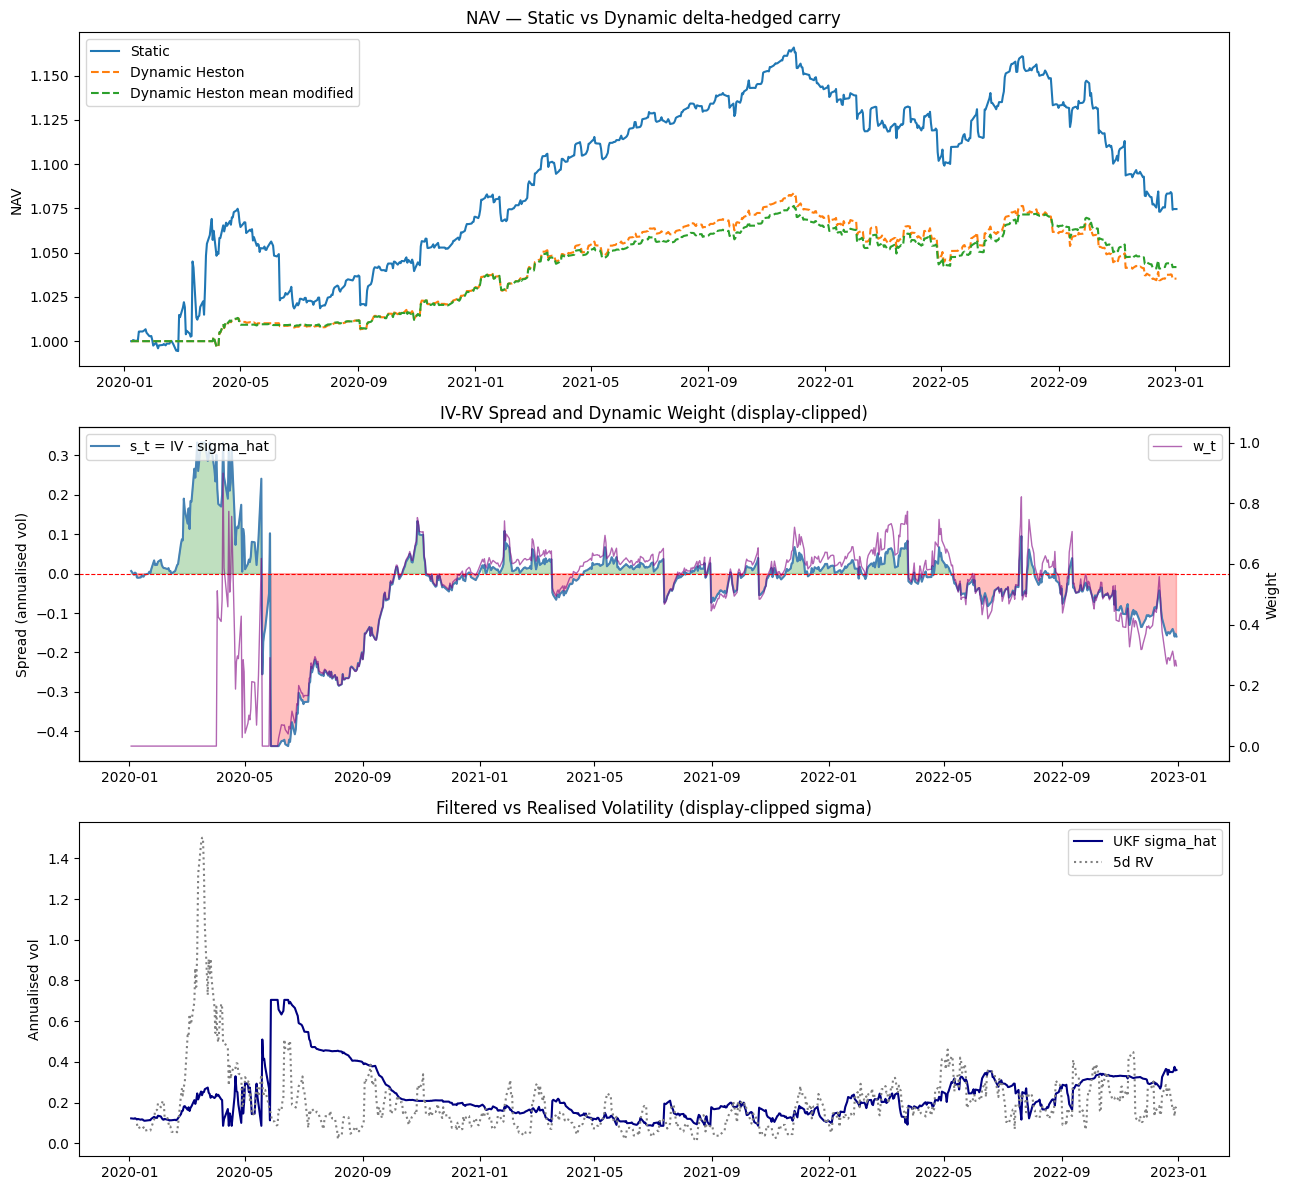

In [43]:
active_case = "heston"  # "heston" or "heston_mean_modified"


case_spreads = {
    "heston": spread_heston,
    "heston_mean_modified": spread_heston_mean_modified,
}
case_weights = {
    "heston": dynamic_weights_heston,
    "heston_mean_modified": dynamic_weights_heston_mean_modified,
}
case_sigma = {
    "heston": kalman_result_heston["sigma_filtered"],
    "heston_mean_modified": kalman_result_heston_mean_modified["sigma_filtered"],
}

plot_results(
    backtester_static=backtester_static,
    backtester_dynamic_heston=backtester_dynamic_heston,
    backtester_dynamic_heston_mean_modified=backtester_dynamic_heston_mean_modified,
    spread=case_spreads[active_case],
    dynamic_weights=case_weights[active_case],
    sigma_filtered=case_sigma[active_case],
    log_returns=log_returns,
)

# 8) Conclusion

Nos résultats indiquent que le portefeuille delta hedgé avec une dynamique d'Heston et un Unscented Kalman Filter (UFK) permet d'obtenir un meilleur compromis entre rendements et risque comme le démontre le ratio de Sharpe. Les rendements sont un peu plus lissés sur la période et le max drawdown est quasiment divisé par deux.

L'introduction du terme de correction d'Itô permet d'améliorer nos résultats de manière globale.